<div>
    <h1>Assignment 9: Random Walk simulation</h1>
    <p style="font-size: 18px;">Sanjeev Kumawat | ph25mscst11026</p>
</div>

In [34]:
#importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [35]:
#parameters
N = 100
l = 1
p = 0.5
walkers = 10000

### Defining functions

In [36]:
#1d random walk simulation
def random_walk_simulation_1d(walkers, steps, p):
    #final positions of each walker
    m = []  
    for i in range(walkers):
        x = 0
        for j in range(steps):
            if np.random.rand() < p:
                x -= l
            else:
                x += l
        m.append(x)
    return np.array(m)


#Calculating mean and mean square of final positions
def statistics_calculations(m, N):
    mean_x = np.mean(m)
    mean_x2 = np.mean(m**2)
    error = abs(mean_x2 - N)
    
    #print results
    print("⟨x⟩ =", mean_x)
    print("⟨x²⟩ =", mean_x2)
    print("Theoretical ⟨x⟩ =", 0)
    print("Theoretical ⟨x²⟩ =", N)
    print("Error in ⟨x²⟩ =", error)


#error analysis for different ensemble sizes
def error_analysis(N, p):
    ensemble_sizes = [10, 100, 500, 1000, 5000, 10000]
    errors_x = []
    errors_x2 = []

    for walkers in ensemble_sizes:
        m = random_walk_simulation_1d(walkers, N, p)
        mean_x = np.mean(m)
        mean_x2 = np.mean(np.array(m)**2)
        error_x = abs(mean_x - 0)
        error_x2 = abs(mean_x2 - N)
        errors_x.append(error_x)
        errors_x2.append(error_x2)

    #plot error vs ensemble size
    plt.plot(ensemble_sizes, errors_x, marker='o', label='Error in ⟨x⟩')
    plt.plot(ensemble_sizes, errors_x2, marker='s', label='Error in ⟨x²⟩')
    plt.xscale("log")
    plt.xlabel("Ensemble Size")
    plt.ylabel("Error")
    plt.title(f"Error vs Ensemble Size (p = {p:.2f})")
    plt.grid(True)
    plt.legend()
    plt.show()


### Setup 1 (1D Random walk simulations)

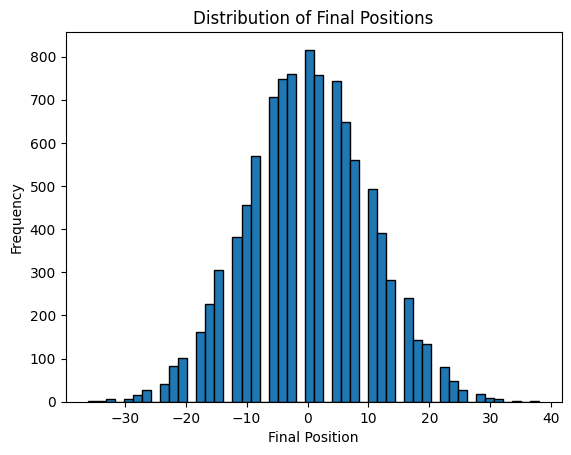

⟨x⟩ = 0.0446
⟨x²⟩ = 101.2612
Theoretical ⟨x⟩ = 0
Theoretical ⟨x²⟩ = 100
Error in ⟨x²⟩ = 1.2612000000000023


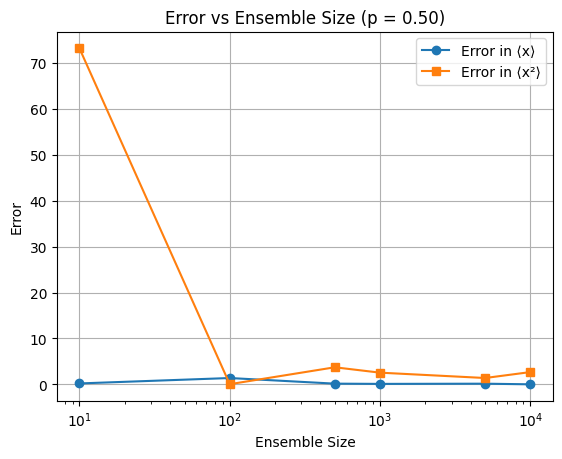

In [37]:
#question1

m1 = random_walk_simulation_1d(walkers, N, p)

#histogram of final positions
plt.hist(m1, bins=50, edgecolor='black')
plt.xlabel("Final Position")
plt.ylabel("Frequency")
plt.title("Distribution of Final Positions")
plt.show()

#results
results = statistics_calculations(m1, N)

#error analysis
error_analysis(N, p)

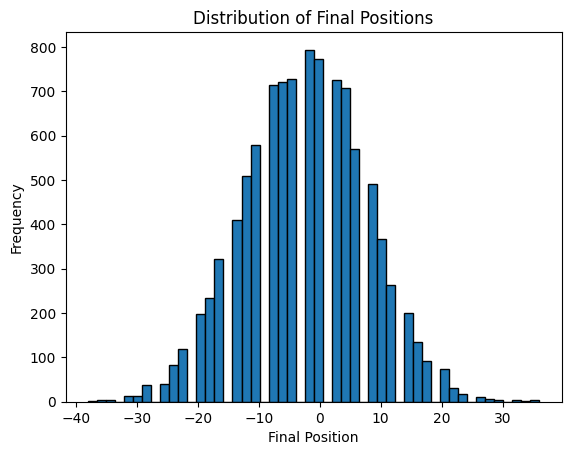

⟨x⟩ = -2.5048
⟨x²⟩ = 105.7928
Theoretical ⟨x⟩ = 0
Theoretical ⟨x²⟩ = 100
Error in ⟨x²⟩ = 5.7928


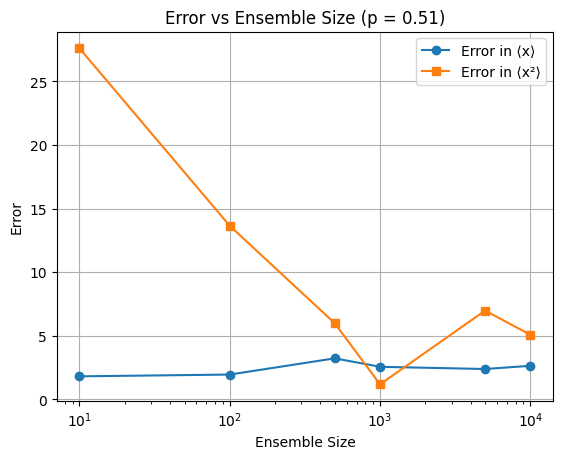

In [38]:
#question2
#dob = 06/07/2006
ddd = 187
pod = ddd/365

m2 = random_walk_simulation_1d(walkers, N , pod)

#histogram of final positions
plt.hist(m2, bins=50, edgecolor='black')
plt.xlabel("Final Position")
plt.ylabel("Frequency")
plt.title("Distribution of Final Positions")
plt.show()

#results
result = statistics_calculations(m2, N)

#error analysis
error_analysis(N, pod)

### Setup 2 (2D Random Walk Simulation)

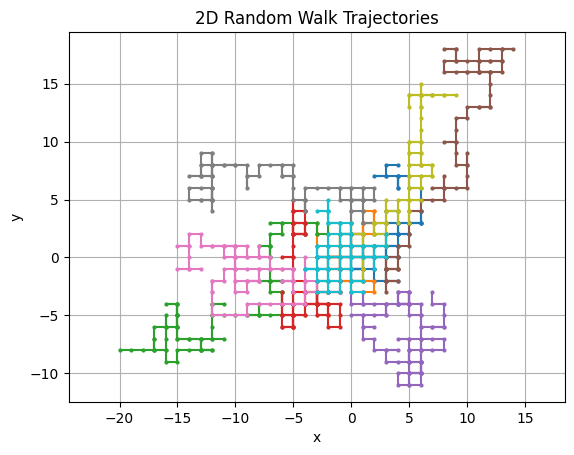

⟨x⟩ = -0.0825
⟨y⟩ = 0.0057
⟨x²⟩ = 50.9573
⟨y²⟩ = 49.1401
⟨r²⟩ = 100.0974
Expected ⟨x⟩ = 0, ⟨y⟩ = 0
Expected ⟨r²⟩ ≈ 2N = 200


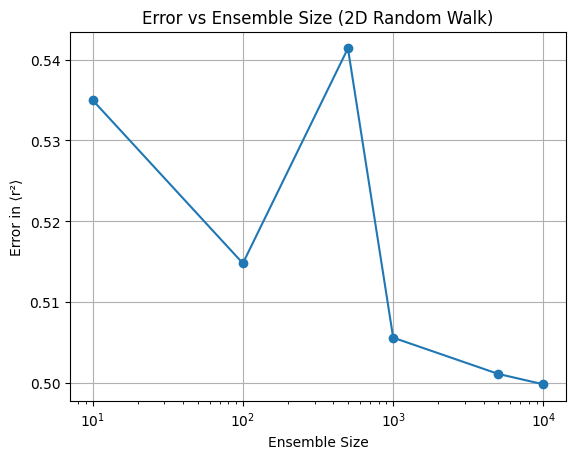

In [39]:
#2d random walk simulation
def random_walk_simulation_2d(walkers, steps, plot=True):
    final_x = []
    final_y = []

    for w in range(walkers):
        x, y = 0, 0
        x_traj = [x]
        y_traj = [y]

        for i in range(steps): 
            r = np.random.rand()

            if r < 0.25:    #left
                x -= 1
            elif r < 0.5:   #right
                x += 1
            elif r < 0.75:  #down
                y -= 1
            else:           #up
                y += 1

            x_traj.append(x)
            y_traj.append(y)

        final_x.append(x)
        final_y.append(y)

        if plot and w < 10:
            plt.plot(x_traj, y_traj, marker='o', markersize=2)

    if plot:
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("2D Random Walk Trajectories")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

    return np.array(final_x), np.array(final_y)

#simulate 2d random walk and collect final positions
x, y = random_walk_simulation_2d(walkers, N)

#statistics
mean_x = np.mean(x)
mean_y = np.mean(y)
mean_x2 = np.mean(x**2)
mean_y2 = np.mean(y**2)
mean_r2 = np.mean(x**2 + y**2)

#print results
print("⟨x⟩ =", mean_x)
print("⟨y⟩ =", mean_y)
print("⟨x²⟩ =", mean_x2)
print("⟨y²⟩ =", mean_y2)
print("⟨r²⟩ =", mean_r2)
print("Expected ⟨x⟩ = 0, ⟨y⟩ = 0")
print("Expected ⟨r²⟩ ≈ 2N =", 2 * N)

#error analysis for different ensemble sizes
ensemble_sizes = [10, 100, 500, 1000, 5000, 10000]
errors = []

for walkers in ensemble_sizes:
    x, y = random_walk_simulation_2d(walkers, N, plot=False)
    mean_r2 = np.mean(x**2 + y**2)
    error = abs(mean_r2 - 2*N) / (2*N)
    errors.append(error)

#plot error vs ensemble size
plt.plot(ensemble_sizes, errors, marker='o')
plt.xlabel("Ensemble Size")
plt.xscale("log")
plt.ylabel("Error in ⟨r²⟩")
plt.title("Error vs Ensemble Size (2D Random Walk)")
plt.grid(True)
plt.show()

### Conclusion and Discussion

The simulation results agree with theory, showing that the mean displacement is close to zero and the mean squared displacement increases with the number of steps, indicating diffusive behavior. The error decreases with increasing ensemble size, although small fluctuations remain due to randomness.

This behavior is similar to Brownian motion, where there is no preferred direction and the particle spreads over time. Thus, the random walk provides a simple model to understand diffusion in Brownian dynamics.